## Strategy 01: Baseline (Raw Imbalanced Dataset)

Establishes reference metrics by training on a naturally imbalanced dataset with no balancing strategy. Demonstrates how class imbalance degrades Macro-F1 and inflates TPRGap.

Because our research is based on the Guilherme's paper, this baseline is also to check if our traning is aligned with theirs. 

In [1]:
import sys
import os
import json

from transformers import AutoTokenizer

# Local imports
sys.path.append(os.path.abspath(".."))

from src.config import DATASETS, MODEL_NAME, SEED, TRAIN_RATIO
from src.data_utils import get_tokenized_dataset
from src.paths import MODELS_DIR
from src.plot_utils import plot_metrics, results_to_dataframe

/home/phmgc/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Tokenization

Safe to re-run — skips datasets that are already cached.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

for author, dataset_names in DATASETS.items():
    for dataset_name in dataset_names:
        for split in ("train", "test"):
            get_tokenized_dataset(
                author, dataset_name, tokenizer,
                split=split, strategy="baseline",
                train_ratio=TRAIN_RATIO, seed=SEED,
            )

Run training and evaluation before the cells below:
```bash
python scripts/train.py --strategy baseline
python scripts/eval.py --strategy baseline
```

## Results

In [2]:
import pandas as pd
from pathlib import Path

# Local results (trained with paper's hyperparameters)
eval_results_file = MODELS_DIR / "baseline" / "eval_results.json"
if not eval_results_file.exists():
    raise FileNotFoundError(f"Evaluation results not found at {eval_results_file}. Run scripts/eval.py first.")

with open(eval_results_file, "r") as f:
    results = json.load(f)

# Paper's baseline results
paper_path = Path("../docs/undersampling_eval_results.json")
with open(paper_path) as f:
    paper_raw = json.load(f)

paper_nunder = {
    entry["dataset"]: next(m for m in entry["methods"] if m["method"] == "baseline")
    for entry in paper_raw
}

print(f"Local results: {len(results)} datasets")
print(f"Paper baseline: {len(paper_nunder)} datasets")

Local results: 4 datasets
Paper baseline: 4 datasets


In [3]:
local_df = results_to_dataframe(results)[["macro_f1", "tpr_gap"]].round(4)
local_df.columns = pd.MultiIndex.from_tuples([("local", c) for c in local_df.columns])

paper_df = pd.DataFrame({
    ds: {"macro_f1": m["macro_f1"], "tpr_gap": m["tpr_gap"]}
    for ds, m in paper_nunder.items()
}).T.rename_axis("dataset")
paper_df.columns = pd.MultiIndex.from_tuples([("paper (baseline)", c) for c in paper_df.columns])

comparison = local_df.join(paper_df, how="outer").sort_index()
comparison

local         paper (baseline)        
                      macro_f1 tpr_gap         macro_f1 tpr_gap
dataset                                                        
cds_reviews             0.9130  0.1604            0.920   0.166
digital_music           0.8541  0.3753            0.878   0.308
luxury_beauty           0.9309  0.1849            0.931   0.156
sentistrength_myspace   0.8587  0.2637            0.810   0.350

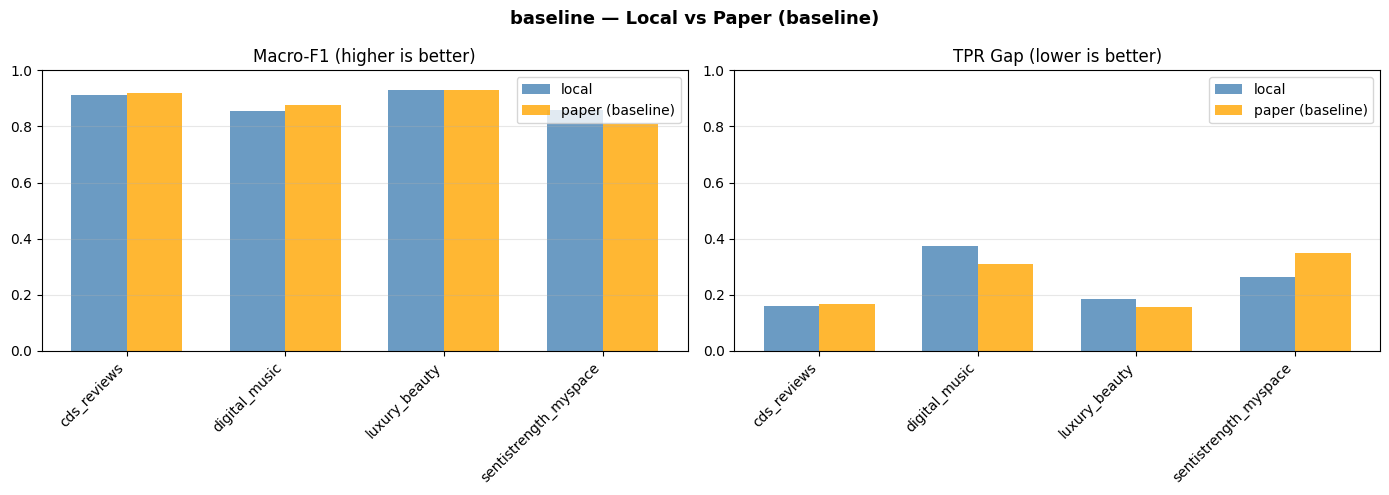

In [4]:
import numpy as np
import matplotlib.pyplot as plt

datasets = comparison.index.tolist()
x = np.arange(len(datasets))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("baseline — Local vs Paper (baseline)", fontsize=13, fontweight="bold")

for ax, metric, title, better in zip(
    axes,
    ["macro_f1", "tpr_gap"],
    ["Macro-F1 (higher is better)", "TPR Gap (lower is better)"],
    ["high", "low"],
):
    local_vals  = comparison[("local", metric)].values.astype(float)
    paper_vals  = comparison[("paper (baseline)", metric)].reindex(datasets).values.astype(float)

    ax.bar(x - width/2, local_vals, width, label="local",          alpha=0.8, color="steelblue")
    ax.bar(x + width/2, paper_vals, width, label="paper (baseline)", alpha=0.8, color="orange")
    ax.set_xticks(x)
    ax.set_xticklabels(datasets, rotation=45, ha="right")
    ax.set_ylim(0, 1)
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Replication Notes

Decisions made to align this pipeline with the original paper's experimental setup:

### 1. Learning rate scheduler
The paper's setup (likely HuggingFace Trainer) applies a **linear warmup + linear decay** schedule by default. Training without warmup caused the model to overwrite RoBERTa's pre-trained representations in the first batches of heavily imbalanced datasets, collapsing to always predict the majority class (TPR Gap = 1.0 for digital_music and cds_reviews).

<div style="font-size: 0.85em; line-height: 1.2;">

```python
total_steps = epochs * len(train_dl)
warmup_steps = int(0.06 * total_steps)	# 6% warmup - HuggingFace Trainer default
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
```
</div>

### 2. Evaluation methodology (known limitation)
The paper reports averages over **10-fold cross-validation**. This pipeline uses a single **80/20 train/test split** for computational feasibility — replicating 10-fold CV on cds_reviews alone would require ~60 hours of GPU time per strategy. Residual differences of 2–7% between local and paper results are attributable to this variance across splits.

## Conclusion

When class imbalance is severe, **TPRGap increases sharply** even when **accuracy remains high**, indicating strong bias toward the majority class.  
When imbalance is moderate or low, the model can learns both classes reasonably well, resulting in a low TPRGap and better-balanced performance (higher Macro-F1).